# **Etude de la saisonalité liée à l'activité humain sur station C**

<h2 style="font-size: 20px; font-weight: bold;">1. Introduction & Objectifs</h2>

Située sur un réseau unitaire, la Station C mêle eaux usées (activité humaine) et pluviales (météo). 

Ce notebook vise à isoler la signature anthropique sur la période 2021-2026 en analysant les cycles annuels, hebdomadaires et journaliers, afin d'établir le profil de débit type hors intempéries.

<h2 style="font-size: 20px; font-weight: bold;">2. Chargement et préparation des données</h2>

Pour mener cette étude, on fusionne les données des fichiers sensor en ne gardant que le débit d'entrée ainsi que la date.

In [17]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [ ]:

file_path_1 = '../Dataset/bronze/sensors_C_20210101_20250101.csv'
file_path_2 = '../Dataset/bronze/sensors_C_20250101_20260108.csv'

df1 = pd.read_csv(file_path_1)
df1 = df1[df1['sensor'] == 'entry_debit']

df2 = pd.read_csv(file_path_2)
df2 = df2[df2['sensor'] == 'entry_debit']

# Fusion
df_c = pd.concat([df1, df2], ignore_index=True)

#  Conversion en datetime
df_c['ts'] = pd.to_datetime(df_c['ts'])

# Nettoyage rapide
df_c['value'] = df_c['value'].clip(lower=0)

# Tri par date pour éviter les problèmes d'affichage
df_c = df_c.sort_values('ts')

print(f"Données prêtes et fusionnées : {len(df_c)} points pour entry_debit")
df_c.head()

Données prêtes et fusionnées : 2425885 points pour entry_debit


,ts,sensor,value
0,2021-01-01 00:00:00,entry_debit,1450.7999
1,2021-01-01 00:01:00,entry_debit,1452.1499
2,2021-01-01 00:02:00,entry_debit,1450.4624
3,2021-01-01 00:03:00,entry_debit,1449.8999
4,2021-01-01 00:04:00,entry_debit,1449.1124


Nous pouvons commencer !

<h2 style="font-size: 20px; font-weight: bold;">3. Saisonalité mensuelle</h2>


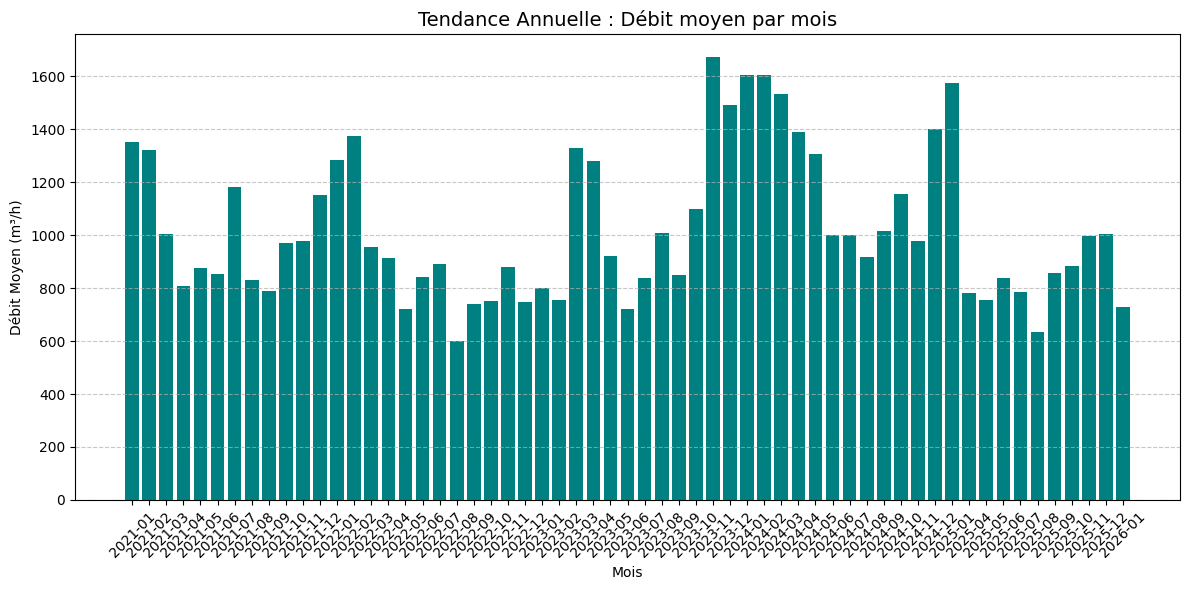

In [29]:
#  Calcul de la moyenne par mois 
df_c['Mois_Annee'] = df_c['ts'].dt.to_period('M')
df_mensuel = df_c.groupby('Mois_Annee')['value'].mean().reset_index()

# Affichage avec Matplotlib (au lieu de Plotly)
plt.figure(figsize=(12, 6)) # On définit la taille

# Création des barres
plt.bar(df_mensuel['Mois_Annee'].astype(str), df_mensuel['value'], color='teal')

# Titres et étiquettes
plt.title("Tendance Annuelle : Débit moyen par mois", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("Débit Moyen (m³/h)")

# Rotation des dates en bas pour que ce soit lisible
plt.xticks(rotation=45)

# Affichage final
plt.grid(axis='y', linestyle='--', alpha=0.7) # Petite grille horizontale pour aider la lecture
plt.tight_layout()
plt.show()

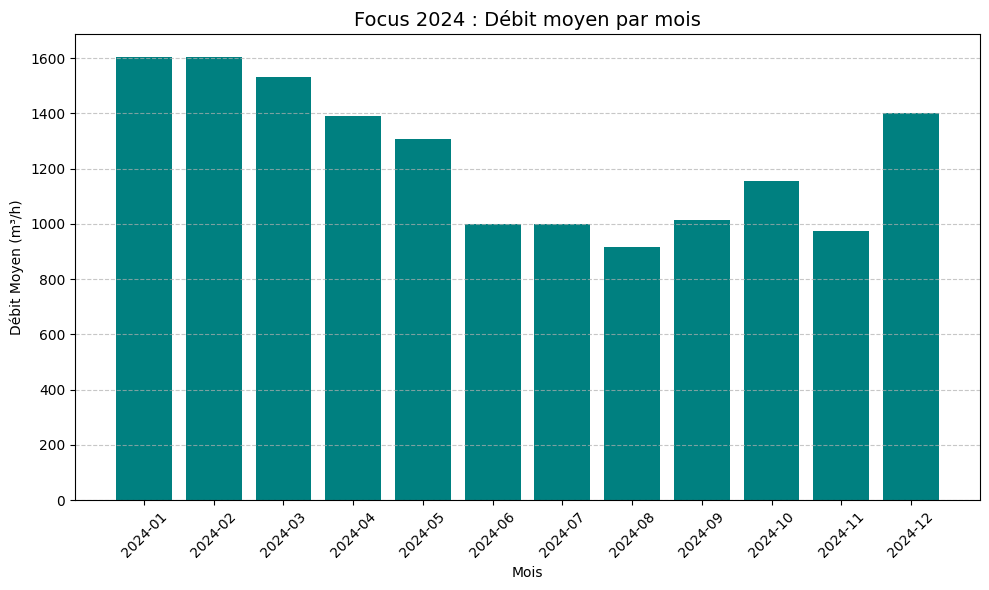

In [ ]:
df_focus = df_c[df_c['ts'].dt.year == 2024].copy()

#  Calcul de la moyenne sur ces données filtrées
df_mensuel = df_focus.groupby('Mois_Annee')['value'].mean().reset_index()

# Affichage Matplotlib
plt.figure(figsize=(10, 6))

plt.bar(df_mensuel['Mois_Annee'].astype(str), df_mensuel['value'], color='teal')

plt.title("Focus 2024 : Débit moyen par mois", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("Débit Moyen (m³/h)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<h2 style="font-size: 20px; font-weight: bold;">4. Saisonalité hébdomadaire</h2>


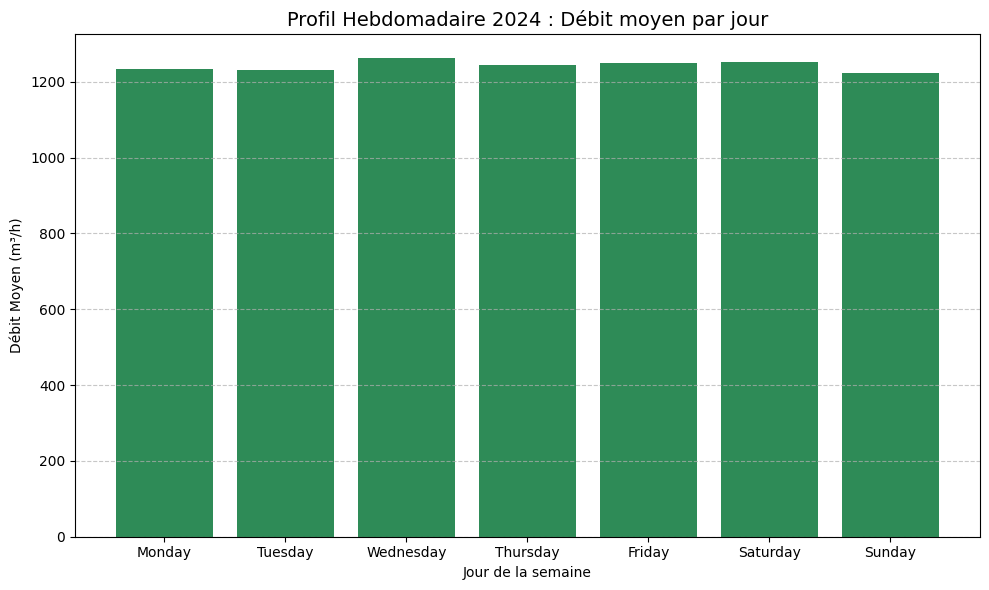

In [ ]:
# On ne garde que l'année 2024
df_2024 = df_c[df_c['ts'].dt.year == 2024].copy()

# Extraction du jour de la semaine
df_2024['Jour_Semaine'] = df_2024['ts'].dt.day_name()

# On définit l'ordre des jours
ordre_jours = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

#  Calcul de la moyenne par jour
df_hebdo = df_2024.groupby('Jour_Semaine')['value'].mean().reindex(ordre_jours).reset_index()

# Affichage Matplotlib
plt.figure(figsize=(10, 6))

plt.bar(df_hebdo['Jour_Semaine'], df_hebdo['value'], color='seagreen') # J'ai changé la couleur en vert pour différencier

plt.title("Profil Hebdomadaire 2024 : Débit moyen par jour", fontsize=14)
plt.xlabel("Jour de la semaine")
plt.ylabel("Débit Moyen (m³/h)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

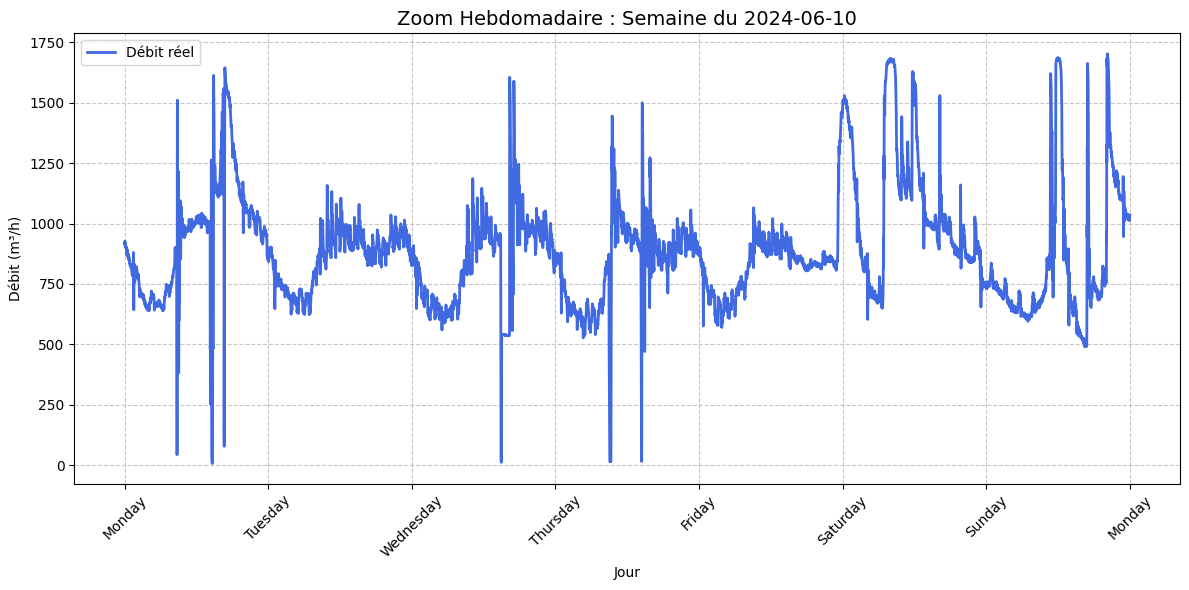

In [ ]:
# Définition de la semaine cible 
start_date = '2024-06-10' # Lundi
end_date = '2024-06-17'   # Lundi suivant (exclu)

# Filtrage
df_semaine = df_c[(df_c['ts'] >= start_date) & (df_c['ts'] < end_date)].copy()

# Affichage de la courbe réelle
plt.figure(figsize=(12, 6))

# On trace la courbe brute
plt.plot(df_semaine['ts'], df_semaine['value'], color='royalblue', linewidth=2, label='Débit réel')


plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%A')) 

plt.title(f"Zoom Hebdomadaire : Semaine du {start_date}", fontsize=14)
plt.ylabel("Débit (m³/h)")
plt.xlabel("Jour")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

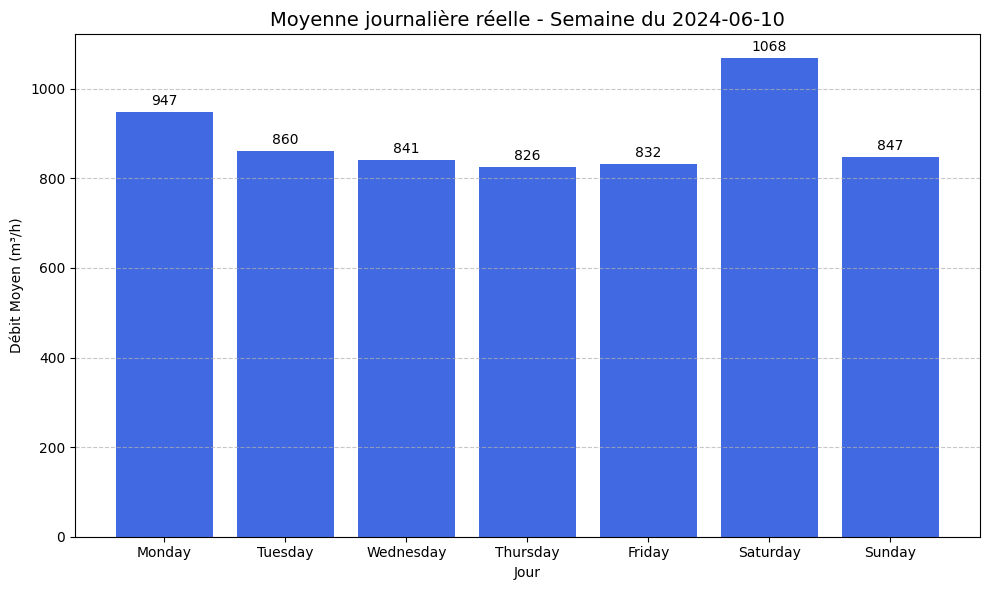

In [ ]:
# Semaine cible
start_date = '2024-06-10'
end_date = '2024-06-17'

# Filtrage
mask = (df_c['ts'] >= start_date) & (df_c['ts'] < end_date)
df_semaine = df_c.loc[mask].copy()

# Calcul de la moyenne PAR JOUR
df_moyenne_jour = df_semaine.groupby(df_semaine['ts'].dt.date)['value'].mean().reset_index()
df_moyenne_jour.columns = ['Date', 'Debit_Moyen'] # On renomme proprement

#  Création d'une colonne pour le nom du jour (Lundi, Mardi...)
df_moyenne_jour['Nom_Jour'] = pd.to_datetime(df_moyenne_jour['Date']).dt.day_name()

# Affichage
plt.figure(figsize=(10, 6))
bars = plt.bar(df_moyenne_jour['Nom_Jour'], df_moyenne_jour['Debit_Moyen'], color='royalblue')

plt.title(f"Moyenne journalière réelle - Semaine du {start_date}", fontsize=14)
plt.ylabel("Débit Moyen (m³/h)")
plt.xlabel("Jour")


plt.bar_label(bars, fmt='%.0f', padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<h2 style="font-size: 20px; font-weight: bold;">5. Saisonalité quotidienne</h2>


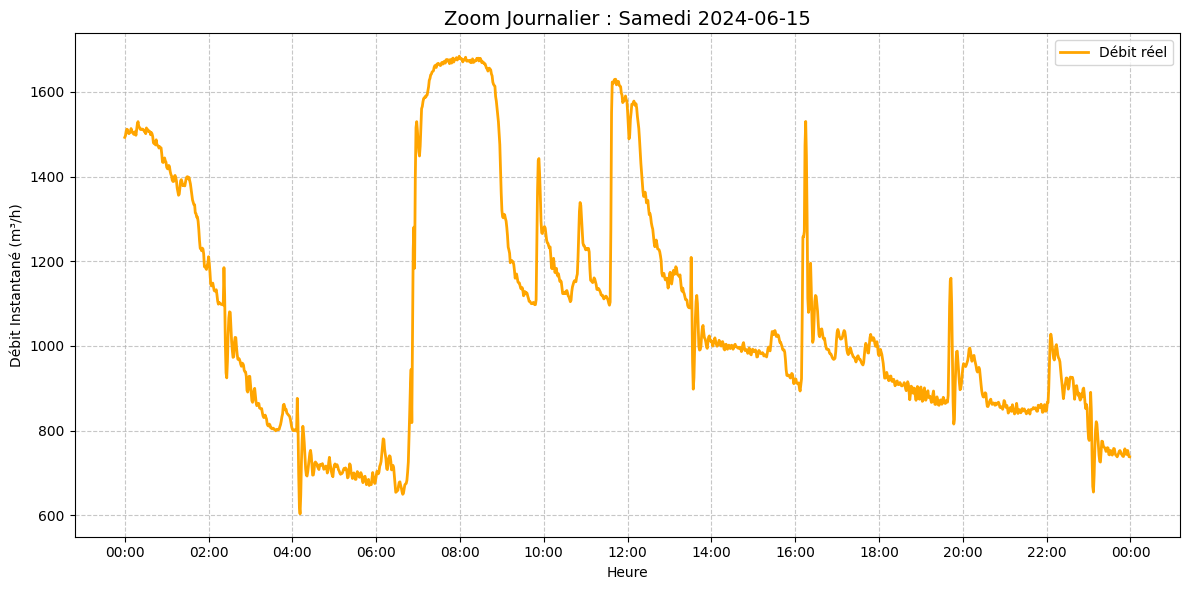

In [ ]:
#  On cible le Samedi 15 Juin 2024
target_date = '2024-06-15'

#  Filtrage sur cette journée unique (de 00h00 à 23h59)
df_samedi = df_c[df_c['ts'].dt.strftime('%Y-%m-%d') == target_date].copy()

#  Affichage de la courbe réelle
plt.figure(figsize=(12, 6))

plt.plot(df_samedi['ts'], df_samedi['value'], color='orange', linewidth=2, label='Débit réel')

#  Mise en forme de l'axe des heures (pour bien voir 0h, 6h, 12h...)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) 
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))  

plt.title(f"Zoom Journalier : Samedi {target_date}", fontsize=14)
plt.xlabel("Heure")
plt.ylabel("Débit Instantané (m³/h)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

<h2 style="font-size: 20px; font-weight: bold;">6. Conclusion</h2>


Une saisonalité anthropique est observable malgrés le bruit (pluie, météo ...etc ) lié au caractère unitaire de la station. 

--> Peut être considéré comme un feature lors d'un modèle prédictif. 